# Part 1: NumPyro and the Bayesian Workflow

We start from basic Bayesian inference in **NumPyro**, then show how to generate and check data using **Predictive** and the **Bayesian workflow**.

## 1.1 Bayesian inference with NumPyro: a minimal example

NumPyro lets you specify a **generative model** (priors and likelihood) and then run inference (e.g. MCMC or SVI). A few key ideas we cover here include:

- **Model**: a Python function that calls `numpyro.sample(...)` for parameters and for data given parameters. The joint distribution is implicit in the execution trace.
- **Inference**: NumPyro provides several inference methods to perform statistical analysis on the model we specify. One popular example we use in this tutorial is No-U-Turn Sampler (NUTS; a form of Hamiltonian Monte Carlo) to draw samples from the posterior.
- **ArviZ**: a library for diagnosing and visualizing MCMC (posteriors, HDI, etc.).


We'll start by setting up our model, which will be **scalar linear regression**; we will assume parameters $a$, $b$, and $\sigma$, with observations generated as

$$
y = ax + b + \varepsilon; \quad \varepsilon \sim \mathcal{N}(0, \sigma^2).
$$

We will observe $(x, y)$ and infer $a$, $b$, and $\sigma$. To do so, we must place priors on these parameters; in this case, we use

\begin{align}
    a &\sim \mathcal{N}(0.0, 2.0^2), \\
    b &\sim \mathcal{N}(0.0, 2.0^2), \\
    \sigma &\sim \mathcal{N}^+(1.0^2),
\end{align}

where $\mathcal{N}^+(1.0^2)$ is a half-normal distribution.

To specify this model in NumPyro, we will write down the priors and likelihood using `numpyro.sample(...)` statements. These statements take in the name of the variable, its distribution, and (optionally) an observation.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist

numpyro.util.set_host_device_count(4)  # to sample chains in parallel later


def linear_regression_model(x, y=None):
    """y = a*x + b + noise. We observe (x, y); infer a, b, sigma."""
    a = numpyro.sample("a", dist.Normal(0.0, 2.0))
    b = numpyro.sample("b", dist.Normal(0.0, 2.0))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    mu = a * x + b
    numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

We'll generate some synthetic data the "manual" way for now, but also see in a moment how to use the `Predictive` utility to make this simpler.

In [2]:
# Generate synthetic data: y = a*x + b + noise
key = jr.PRNGKey(0)
a_true, b_true = 1.5, -0.5
sigma_true = 0.3
n = 80
key, kx, kn = jr.split(key, 3)
x_data = jr.uniform(kx, (n,), minval=-2.0, maxval=2.0)
y_data = a_true * x_data + b_true + sigma_true * jr.normal(kn, (n,))

print("True: a =", a_true, ", b =", b_true, ", sigma =", sigma_true)

True: a = 1.5 , b = -0.5 , sigma = 0.3


To perform statistical inference on the model, using the data `(x_data, y_data)`, we can use the built-in inference tools of NumPyro. For the current tutorial, we will use NUTS, an adaptive MCMC method. 

In [3]:
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(linear_regression_model)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=4)
mcmc.run(jr.PRNGKey(1), x=x_data, y=y_data)

posterior_grouped_by_chain = mcmc.get_samples(group_by_chain=True)  # for diagnostics
posterior = mcmc.get_samples(group_by_chain=False)  # for posterior predictive

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

We can then use arviz to visualize the resulting MCMC draws. We first plot the posteriors of $a$, $b$, and $\sigma$, and compare to the reference values we have.

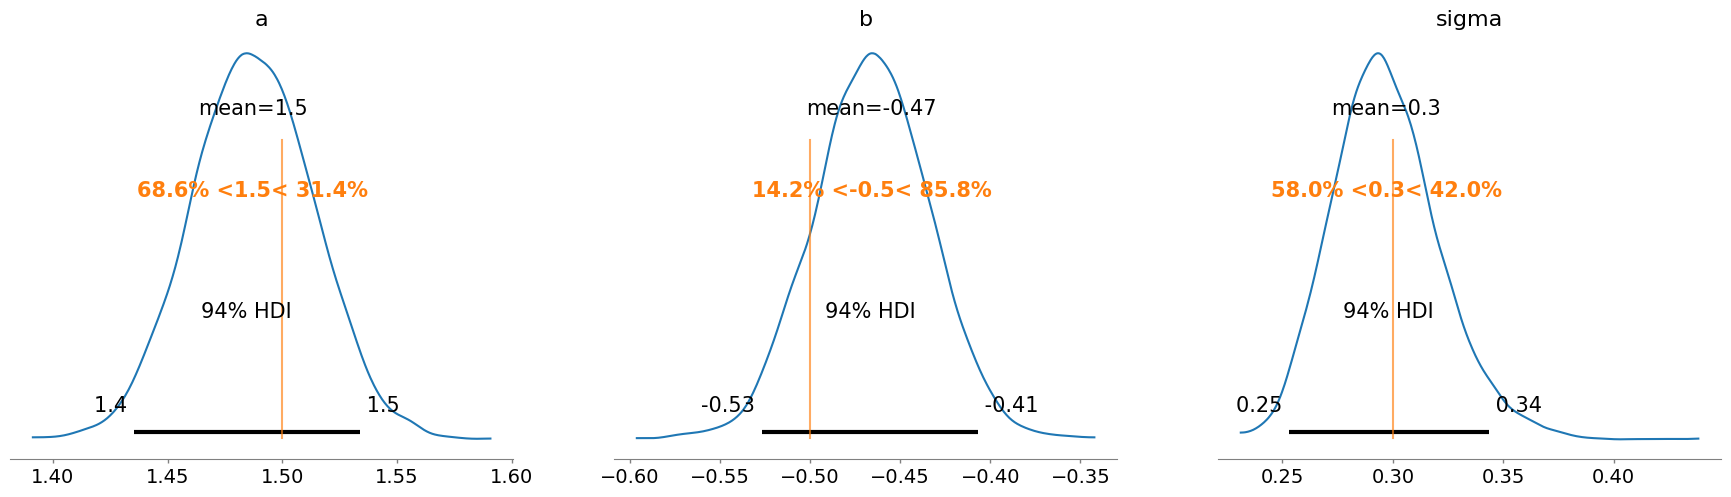

In [4]:
import arviz as az

idata = az.from_dict(posterior=posterior_grouped_by_chain)
az.plot_posterior(
    idata, var_names=["a", "b", "sigma"], ref_val=[a_true, b_true, sigma_true]
);

ArviZ also provides many other diagnostic utilities. Below, we show a forest plot, that illustrates the quartiles of each MCMC chain, as well as its effective sample size (ESS); for more info on MCMC diagnostics and features of ArviZ, see [the ArviZ documentation](https://python.arviz.org/en/v0.23.0/examples/index.html).

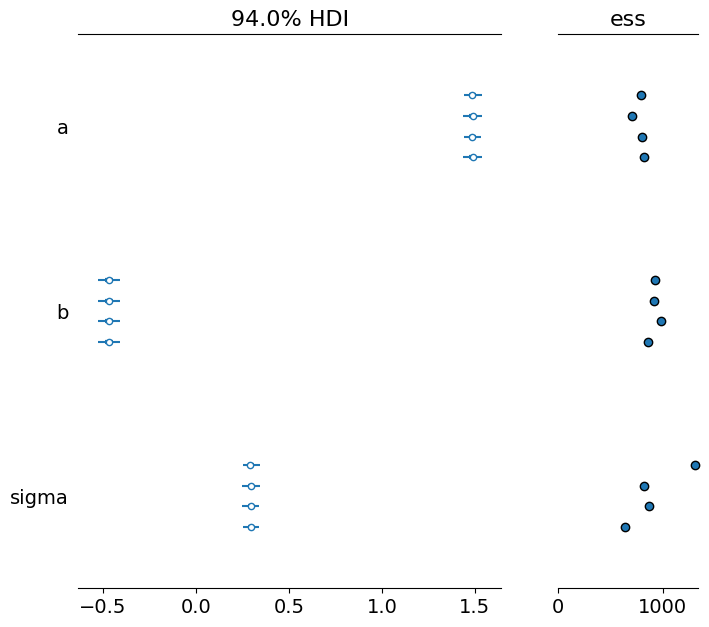

In [5]:
ax = az.plot_forest(
    idata,
    var_names=["a", "b", "sigma"],
    ess=True,
)

## 1.2 Generating data with Predictive, and the Bayesian workflow

Instead of hand-writing $y = a x + b + \text{noise}$, we can **generate data from the model** using NumPyro's `Predictive`. The data-generating process then matches the model exactly. We can also use `Predictive` for **prior predictive** and **posterior predictive** samples—core steps in the [Bayesian workflow](https://arxiv.org/abs/2011.01808) (model building, prior predictive checks, fit, posterior predictive checks).

First, we will generate some data from the prior predictive of our model, but with the parameters $a$, $b$, and $\sigma$ fixed to their "true" values. This is exactly the generative model we specified above "by hand," but using NumPyro machinery instead!

In [6]:
from numpyro.infer import Predictive

x_grid = jnp.linspace(-2, 2, 50)

# (1) Generate data from the model with fixed parameters (like our "true" data)
prior_predictive_fixed = Predictive(
    linear_regression_model,
    num_samples=4,
    params={
        "a": jnp.array(a_true),
        "b": jnp.array(b_true),
        "sigma": jnp.array(sigma_true),
    },
)
prior_pred_fixed = prior_predictive_fixed(jr.PRNGKey(2), x=x_grid)

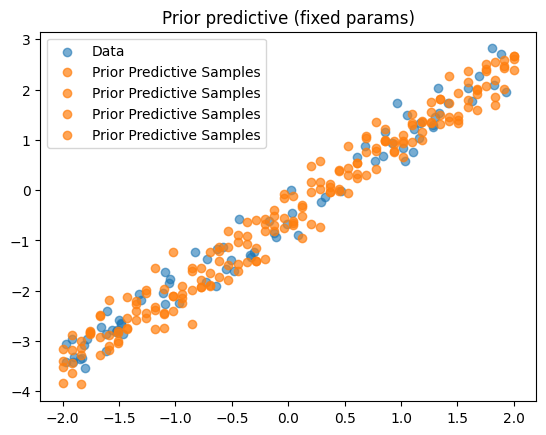

In [7]:
import matplotlib.pyplot as plt

plt.scatter(x_data, y_data, alpha=0.6, label="Data")
for i in range(min(4, prior_pred_fixed["y"].shape[0])):
    plt.scatter(
        x_grid,
        prior_pred_fixed["y"][i],
        alpha=0.7,
        marker="o",
        color="C1",
        label="Prior Predictive Samples",
    )
plt.title("Prior predictive (fixed params)")
plt.legend()

plt.show()

The first step in the Bayesian workflow after specifying an initial model is to perform a "prior predictive check." The idea here is to check that our model (including the priors we used) generate realistic-looking data, in the sense that real behavior is plausible under the prior. 

In [8]:
# (2) Prior predictive: sample (a, b, sigma) from prior, then y | x
prior_predictive_full = Predictive(linear_regression_model, num_samples=20)
prior_pred_full = prior_predictive_full(jr.PRNGKey(3), x=x_grid)

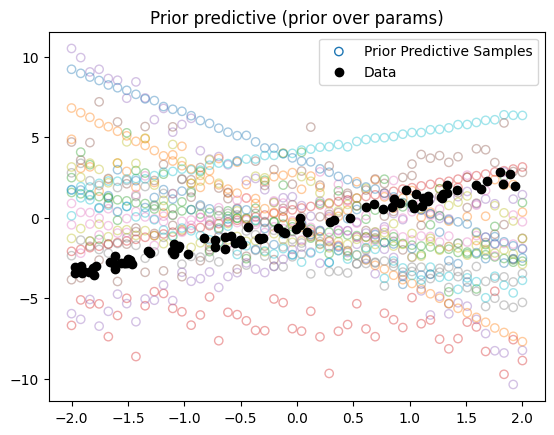

In [9]:
for i in range(prior_pred_full["y"].shape[0]):
    plt.scatter(
        x_grid,
        prior_pred_full["y"][i],
        alpha=0.4,
        edgecolors=f"C{i + 1}",
        facecolors="none",
    )

plt.scatter(
    [], [], label="Prior Predictive Samples", edgecolors="C0", facecolors="none"
)
plt.scatter(x_data, y_data, alpha=1.0, label="Data", color="black")
plt.title("Prior predictive (prior over params)")
plt.legend()

plt.show()

Skipping several steps (once again, check out the excellent [Bayesian Workflow monograph](https://arxiv.org/abs/2011.01808) for more details), a critical evaluation step in the Bayesian workflow is a posterior predictive check, where we use the posterior distribution to check that the model outputs reasonable alternative data. 

In [10]:
# (3) Posterior predictive: sample (a, b, sigma) from posterior, then y | x
posterior_predictive = Predictive(
    linear_regression_model,
    posterior_samples=posterior,
    num_samples=4_000,
)
post_pred = posterior_predictive(jr.PRNGKey(4), x=x_grid)

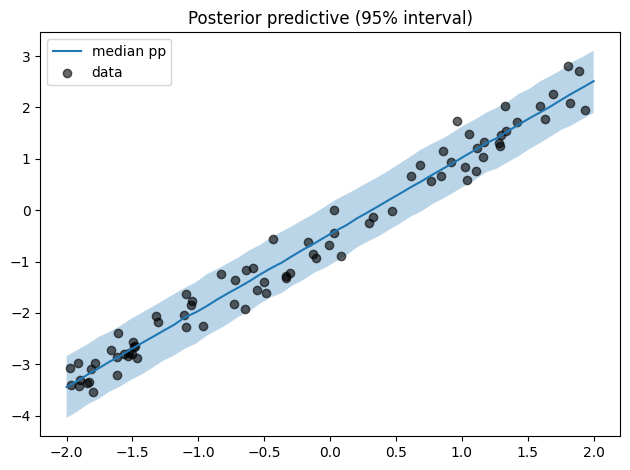

In [11]:
y_pp = post_pred["y"]
plt.fill_between(
    x_grid,
    jnp.percentile(y_pp, 2.5, axis=0),
    jnp.percentile(y_pp, 97.5, axis=0),
    alpha=0.3,
)
plt.plot(x_grid, jnp.median(y_pp, axis=0), color="C0", label="median pp")
plt.scatter(x_data, y_data, alpha=0.6, color="black", label="data")
plt.title("Posterior predictive (95% interval)")
plt.legend()
plt.tight_layout()
plt.show()

**Next:** [Part 2 — Dynestyx: discrete-time dynamical systems](../02_dynestyx_discrete_intro.ipynb)